Project: Exploratory Data Analysis (EDA)

Date: June 2026

Key Findings
1. Product Revenue Performance
Revenue Concentration: Gross revenue is heavily skewed by a small number of high-tier products. Côte de Blaye is the top revenue driver, generating $141,396.74 and outperforming the next closest item (Thüringer Rostbratwurst) by over $60,000.

Risk: Gross revenue is highly vulnerable to supply disruptions or stockouts of this specific wine product.

2. Customer Concentration ("Whales")
Account Dependency: QUICK-Stop is a critical high-value account, generating $110,277.31 across 28 orders.

Purchasing Behavior: While purchasing mid-tier goods in high volume (Camembert Pierrot, 243 units), nearly 20% of their total lifetime spend ($22,924.50) is concentrated in just 90 units of Côte de Blaye.

Risk: Loss of this single customer would significantly impact total wine revenue.

3. Supply Chain & Fulfillment Logistics
Transit Latency: Shipping to Ireland incurs the longest average fulfillment delay in the international network.

Missed Deadlines: Volume hubs in Germany and the USA maintain reasonable average shipping speeds (~8 days) but account for the highest volume of missed customer deadlines (4 and 7 late orders, respectively).

Target Actions: Review the freight pipeline into Ireland to minimize transit latency, and scale up fulfillment capacity in the US and Germany to reduce late deliveries.

In [688]:
import os
import psycopg2
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  
import seaborn as sns

# Load environment variables and connect
load_dotenv()
DATABASE_URL = os.getenv("NEON_DATABASE_URL")

try:
    conn = psycopg2.connect(DATABASE_URL)
    print("✅ Successfully connected to Neon database!")
except Exception as e:
    print(f"Connection error: {e}")

✅ Successfully connected to Neon database!


In [689]:
tables = ['customers', 'orders', 'products', 'order_details']

for table in tables:
    df_check = pd.read_sql(f"SELECT * FROM {table} LIMIT 1;", con=conn)
    print(f"--- {table} columns ---")
    print(df_check.columns.tolist(), "\n")

--- customers columns ---
['customerID', 'companyName', 'contactName', 'contactTitle', 'address', 'city', 'region', 'postalCode', 'country', 'phone', 'fax'] 

--- orders columns ---
['orderID', 'customerID', 'employeeID', 'orderDate', 'requiredDate', 'shippedDate', 'shipVia', 'freight', 'shipName', 'shipAddress', 'shipCity', 'shipRegion', 'shipPostalCode', 'shipCountry'] 

--- products columns ---
['productID', 'productName', 'supplierID', 'categoryID', 'quantityPerUnit', 'unitPrice', 'unitsInStock', 'unitsOnOrder', 'reorderLevel', 'discontinued'] 

--- order_details columns ---
['orderID', 'productID', 'unitPrice', 'quantity', 'discount'] 



C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\2105905556.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql(f"SELECT * FROM {table} LIMIT 1;", con=conn)


In [690]:
import pandas as pd


meta_query = """
SELECT table_name, column_name 
FROM information_schema.columns 
WHERE table_schema='public' 
  AND table_name IN ('products', 'order_details')
ORDER BY table_name, ordinal_position;
"""

df_columns = pd.read_sql(meta_query, con=conn)
print(df_columns.to_string())

       table_name      column_name
0   order_details          orderID
1   order_details        productID
2   order_details        unitPrice
3   order_details         quantity
4   order_details         discount
5        products        productID
6        products      productName
7        products       supplierID
8        products       categoryID
9        products  quantityPerUnit
10       products        unitPrice
11       products     unitsInStock
12       products     unitsOnOrder
13       products     reorderLevel
14       products     discontinued


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\2692857299.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_columns = pd.read_sql(meta_query, con=conn)


In [691]:
# Look at the first 5 rows of the products table
print("--- Products Table Sample ---")
df_p_sample = pd.read_sql('SELECT "productID", "productName" FROM products LIMIT 5;', con=conn)
print(df_p_sample)
print(f"Product ID Data Type: {df_p_sample['productID'].dtype}\n")


print("--- Order Details Table Sample ---")
df_od_sample = pd.read_sql('SELECT "productID", "quantity" FROM order_details LIMIT 5;', con=conn)
print(df_od_sample)
print(f"Order Details Product ID Data Type: {df_od_sample['productID'].dtype}")

--- Products Table Sample ---
   productID                   productName
0          1                          Chai
1          2                         Chang
2          3                 Aniseed Syrup
3          4  Chef Anton's Cajun Seasoning
4          5        Chef Anton's Gumbo Mix
Product ID Data Type: int64

--- Order Details Table Sample ---
   productID  quantity
0         11        12
1         42        10
2         72         5
3         14         9
4         51        40
Order Details Product ID Data Type: int64


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\730452929.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p_sample = pd.read_sql('SELECT "productID", "productName" FROM products LIMIT 5;', con=conn)
C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\730452929.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_od_sample = pd.read_sql('SELECT "productID", "quantity" FROM order_details LIMIT 5;', con=conn)


In [692]:
tables_to_count = ['customers', 'orders', 'products', 'order_details']

for table in tables_to_count:
    count_query = f"SELECT COUNT(*) FROM {table};"
    df_count = pd.read_sql(count_query, con=conn)
    row_count = df_count.iloc[0, 0]
    print(f"Table '{table}' has {row_count} rows.")

Table 'customers' has 67 rows.
Table 'orders' has 654 rows.
Table 'products' has 77 rows.
Table 'order_details' has 2155 rows.


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\1322206041.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count = pd.read_sql(count_query, con=conn)


In [693]:
query_top_products = """
SELECT 
    p."productName",
    SUM(od."unitPrice" * od."quantity" * (1.0 - od."discount")) AS total_revenue
FROM order_details od
JOIN products p ON od."productID" = p."productID"
GROUP BY p."productName"
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_top_products = pd.read_sql(query_top_products, con=conn)
df_top_products.rename(columns={'productName': 'Product Name', 'total_revenue': 'Total Revenue'}, inplace=True)
df_top_products.set_index('Product Name', inplace=True)
df_top_products.head(10)

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\4083832833.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_products = pd.read_sql(query_top_products, con=conn)


,Total Revenue
Product Name,
Côte de Blaye,141396.735
Thüringer Rostbratwurst,80368.672
Raclette Courdavault,71155.700
Tarte au sucre,47234.970
Camembert Pierrot,46825.480
Gnocchi di nonna Alice,42593.060
Manjimup Dried Apples,41819.650
Alice Mutton,32698.380
Carnarvon Tigers,29171.875


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\4011919753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = df_top_products['Total Revenue'], y = df_top_products.index, data = df_top_products, palette='viridis')


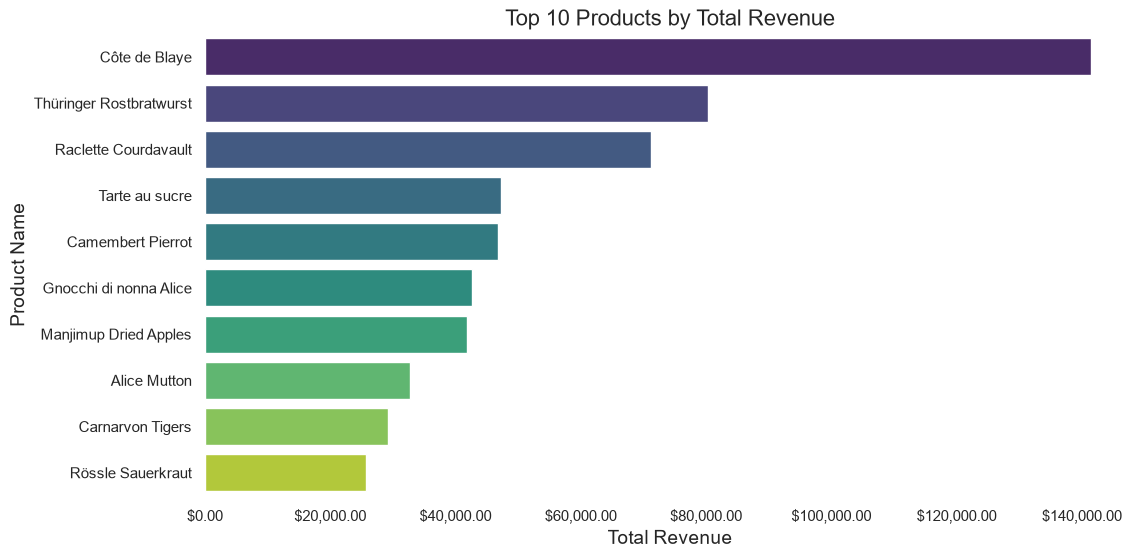

In [694]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x = df_top_products['Total Revenue'], y = df_top_products.index, data = df_top_products, palette='viridis')
plt.title('Top 10 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=14)
plt.ylabel('Product Name', fontsize=14)

formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.2f}')
ax.xaxis.set_major_formatter(formatter)

sns.despine(left=True, bottom=True)


plt.show()

In [695]:
query_top_customers = """
SELECT
    c."companyName",
    COUNT(DISTINCT o."orderID") AS total_orders,
    SUM(od."unitPrice" * od."quantity" * (1.0 - od."discount")) AS total_spent
FROM customers c
JOIN orders o ON c."customerID" = o."customerID"
JOIN order_details od ON o."orderID" = od."orderID"
GROUP BY c."companyName"
ORDER BY total_spent DESC
LIMIT 10;
"""

df_top_customers = pd.read_sql(query_top_customers, con=conn)
df_top_customers.rename(columns={'companyName': 'Company Name', 'total_orders': 'Total Orders', 'total_spent': 'Total Spent'}, inplace=True)
df_top_customers.set_index('Company Name', inplace=True)
df_top_customers.head(10)

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\44555350.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_customers = pd.read_sql(query_top_customers, con=conn)


,Total Orders,Total Spent
Company Name,,
QUICK-Stop,28,110277.3050
Ernst Handel,30,104874.9785
Save-a-lot Markets,31,104361.9500
Rattlesnake Canyon Grocery,18,51097.8005
Hungry Owl All-Night Grocers,19,49979.9050
Königlich Essen,14,30908.3840
Folk och fä HB,19,29567.5625
Mère Paillarde,13,28872.1900
White Clover Markets,14,27363.6050


In [696]:
query_quickstop_products = """
SELECT 
    p."productName",
    SUM(od.quantity) AS total_quantity_bought,
    SUM(od."unitPrice" * od.quantity * (1.0 - od.discount)) AS total_spent_on_product
FROM customers c
JOIN orders o ON c."customerID" = o."customerID"
JOIN order_details od ON o."orderID" = od."orderID"
JOIN products p ON od."productID" = p."productID"
WHERE c."companyName" = 'QUICK-Stop'
GROUP BY p."productName"
ORDER BY total_spent_on_product DESC
LIMIT 5;
"""
df_quickstop_products = pd.read_sql(query_quickstop_products, con=conn)
df_quickstop_products.rename(columns={'productName': 'Product Name', 'total_quantity_bought': 'Total Quantity Bought', 'total_spent_on_product': 'Total Spent'}, inplace=True)
df_quickstop_products.set_index('Product Name', inplace=True)
df_quickstop_products.head(100)   

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\2173940047.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_quickstop_products = pd.read_sql(query_quickstop_products, con=conn)


,Total Quantity Bought,Total Spent
Product Name,,
Côte de Blaye,90.0,22924.5
Camembert Pierrot,243.0,6800.0
Schoggi Schokolade,120.0,5268.0
Thüringer Rostbratwurst,40.0,4951.6
Uncle Bob's Organic Dried Pears,135.0,4050.0


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\316988730.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df_top_products['Total Revenue'], y = df_top_products.index, data = df_top_products, palette='viridis', ax=ax1)
C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\316988730.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df_quickstop_products['Total Quantity Bought'], y = df_quickstop_products.index, data = df_quickstop_products, palette='magma', ax=ax2)


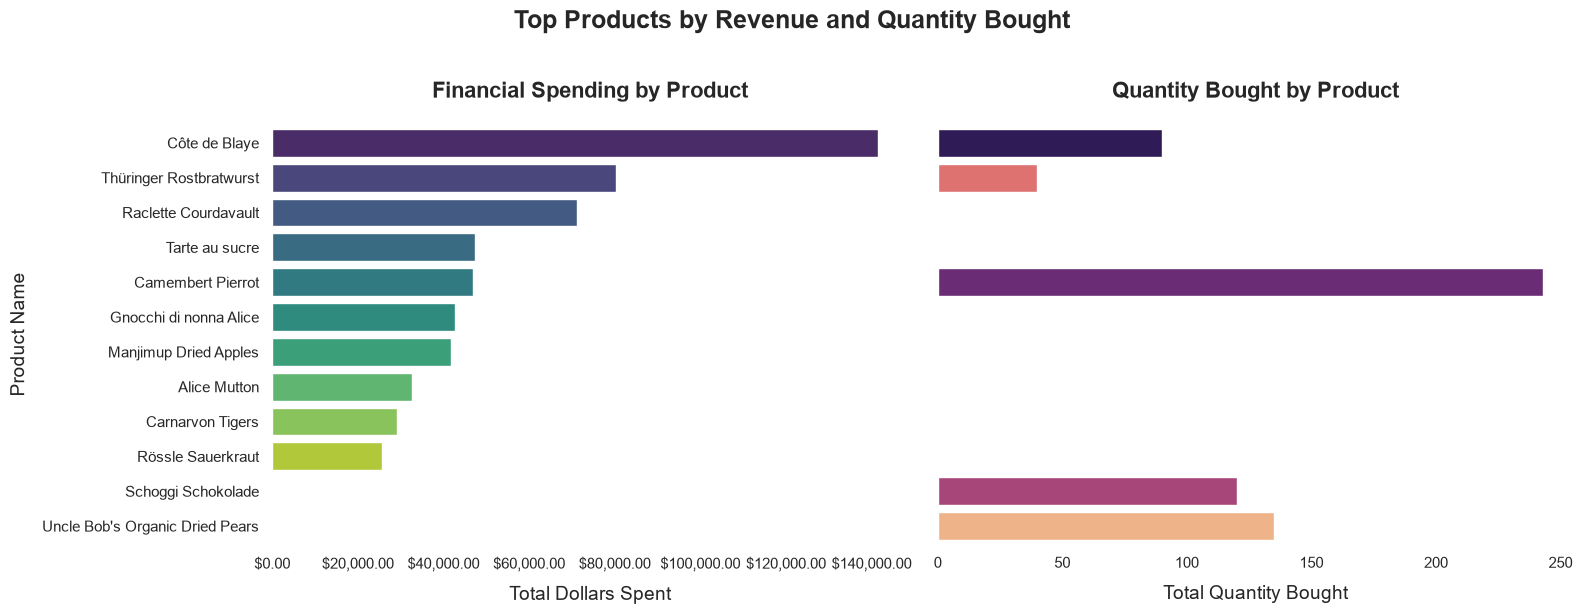

In [697]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.set_theme(style="whitegrid")

sns.barplot(x = df_top_products['Total Revenue'], y = df_top_products.index, data = df_top_products, palette='viridis', ax=ax1)
ax1.set_title("Financial Spending by Product", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Total Dollars Spent", fontsize=14, labelpad=10)
ax1.set_ylabel("Product Name", fontsize=14, labelpad=10)

formatter1 = ticker.FuncFormatter(lambda x, pos: f'${x:,.2f}')
ax1.xaxis.set_major_formatter(formatter1)


sns.barplot(x = df_quickstop_products['Total Quantity Bought'], y = df_quickstop_products.index, data = df_quickstop_products, palette='magma', ax=ax2)
ax2.set_title("Quantity Bought by Product", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel("Total Quantity Bought", fontsize=14, labelpad=10)
ax2.set_ylabel("Product Name", fontsize=14, labelpad=10)

formatter2 = ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
ax2.xaxis.set_major_formatter(formatter2)

sns.despine(left=True, bottom=True, ax=ax1)
sns.despine(left=True, bottom=True, ax=ax2)

plt.suptitle("Top Products by Revenue and Quantity Bought", fontsize=18, fontweight='bold', y=1.02)                    
plt.tight_layout()
plt.show()

In [698]:
query_shipping_sample = """
SELECT "orderID", "shipCountry", "orderDate", "shippedDate", "requiredDate"
FROM orders
WHERE "shippedDate" IS NOT NULL
LIMIT 5;
"""
df_shipping_sample = pd.read_sql(query_shipping_sample, con=conn)
df_shipping_sample

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\2110977949.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_shipping_sample = pd.read_sql(query_shipping_sample, con=conn)


,orderID,shipCountry,orderDate,shippedDate,requiredDate
0,10248,France,1996-07-04 00:00:00.000,1996-07-16 00:00:00.000,1996-08-01 00:00:00.000
1,10249,Germany,1996-07-05 00:00:00.000,1996-07-10 00:00:00.000,1996-08-16 00:00:00.000
2,10254,Switzerland,1996-07-11 00:00:00.000,1996-07-23 00:00:00.000,1996-08-08 00:00:00.000
3,10255,Switzerland,1996-07-12 00:00:00.000,1996-07-15 00:00:00.000,1996-08-09 00:00:00.000
4,10257,Venezuela,1996-07-16 00:00:00.000,1996-07-22 00:00:00.000,1996-08-13 00:00:00.000


In [699]:
query_shipping_delays = """
SELECT 
    "shipCountry",
    COUNT("orderID") AS total_orders,
    ROUND(AVG("shippedDate"::date - "orderDate"::date), 2) AS avg_days_to_ship,
    SUM(CASE WHEN "shippedDate" > "requiredDate" THEN 1 ELSE 0 END) AS late_shipments
FROM orders
WHERE "shippedDate" IS NOT NULL
GROUP BY "shipCountry"
ORDER BY avg_days_to_ship DESC;
"""
df_shipping_delays = pd.read_sql(query_shipping_delays, con=conn)
df_shipping_delays.rename(columns={'shipCountry': 'Ship Country', 'total_orders': 'Total Orders', 'avg_days_to_ship': 'Avg Days to Ship', 'late_shipments': 'Late Shipments'}, inplace=True)
df_shipping_delays.set_index('Ship Country', inplace=True)
df_shipping_delays.head(100)

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\1137929510.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_shipping_delays = pd.read_sql(query_shipping_delays, con=conn)


,Total Orders,Avg Days to Ship,Late Shipments
Ship Country,,,
Ireland,19,11.00,3
Sweden,37,10.22,3
Switzerland,17,9.94,0
USA,119,9.55,7
France,18,9.44,0
Argentina,14,9.29,1
Belgium,7,9.00,0
Portugal,13,8.69,1
Austria,38,8.66,1


C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\3298052923.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = df_top_delays['Avg Days to Ship'], y = df_top_delays.index, data = df_top_delays, palette='coolwarm')


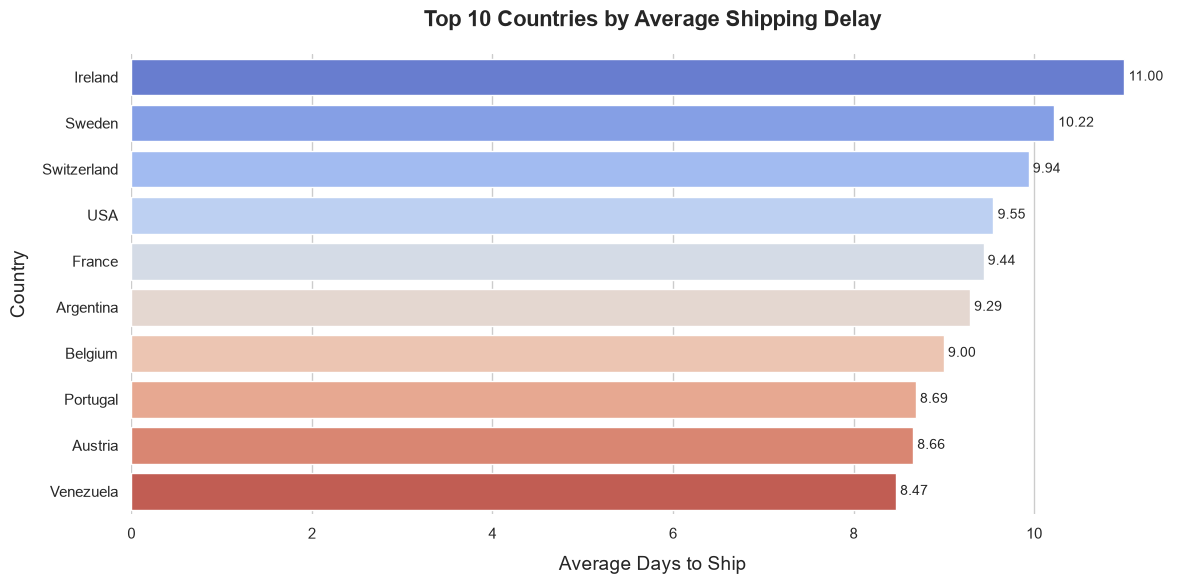

In [700]:
df_top_delays = df_shipping_delays.sort_values(by='Avg Days to Ship', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x = df_top_delays['Avg Days to Ship'], y = df_top_delays.index, data = df_top_delays, palette='coolwarm')  
plt.title("Top 10 Countries by Average Shipping Delay", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Average Days to Ship", fontsize=14, labelpad=10) 
plt.ylabel("Country", fontsize=14, labelpad=10)  
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [701]:
query_rfm_base = """
WITH database_anchor AS (
    SELECT MAX("orderDate"::date) AS max_db_date FROM orders
)
SELECT 
    c."companyName",
    (SELECT max_db_date FROM database_anchor) - MAX(o."orderDate"::date) AS recency,
    COUNT(DISTINCT o."orderID") AS frequency,
    ROUND(SUM(od."unitPrice" * od.quantity * (1.0 - od.discount))::numeric, 2) AS monetary
FROM customers c
JOIN orders o ON c."customerID" = o."customerID"
JOIN order_details od ON o."orderID" = od."orderID"
GROUP BY c."companyName"
ORDER BY monetary DESC;
"""

df_rfm = pd.read_sql(query_rfm_base, con=conn)
df_rfm_clean = df_rfm.set_index('companyName')
df_rfm_clean.rename(columns={'recency': 'Days Since Last Order', 'frequency': 'Total Orders', 'monetary': 'Money Spent ($)'}, inplace=True)  
df_rfm_clean.sort_values(by='Money Spent ($)', ascending=False, inplace=True)
df_rfm_clean.head(10)

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\1579364809.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rfm = pd.read_sql(query_rfm_base, con=conn)


,Days Since Last Order,Total Orders,Money Spent ($)
companyName,,,
QUICK-Stop,22,28,110277.31
Ernst Handel,1,30,104874.98
Save-a-lot Markets,5,31,104361.95
Rattlesnake Canyon Grocery,0,18,51097.80
Hungry Owl All-Night Grocers,6,19,49979.91
Königlich Essen,20,14,30908.38
Folk och fä HB,9,19,29567.56
Mère Paillarde,188,13,28872.19
White Clover Markets,5,14,27363.61


In [702]:
query_rfm_scores = """
WITH database_anchor AS (
    SELECT MAX("orderDate"::date) AS max_db_date FROM orders
),
rfm_base AS (
    SELECT 
        c."companyName",
        (SELECT max_db_date FROM database_anchor) - MAX(o."orderDate"::date) AS recency,
        COUNT(DISTINCT o."orderID") AS frequency,
        SUM(od."unitPrice" * od.quantity * (1.0 - od.discount)) AS monetary
    FROM customers c
    JOIN orders o ON c."customerID" = o."customerID"
    JOIN order_details od ON o."orderID" = od."orderID"
    GROUP BY c."companyName"
)
SELECT 
    "companyName",
    recency,
    frequency,
    ROUND(monetary::numeric, 2) AS monetary,
    NTILE(5) OVER (ORDER BY recency DESC) AS r_score,    -- Longest days away get 1, 0 days (freshest) get 5
    NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,  -- Lowest frequency gets 1, highest gets 5
    NTILE(5) OVER (ORDER BY monetary ASC) AS m_score    -- Lowest spend gets 1, highest gets 5
FROM rfm_base;
"""

df_rfm_scored = pd.read_sql(query_rfm_scores, con=conn)
df_rfm_scored.set_index('companyName', inplace=True)
df_rfm_scored.rename(columns={'recency': 'Days Since Last Order', 'frequency': 'Total Orders', 'monetary': 'Money Spent ($)', 'r_score': 'Recency Score', 'f_score': 'Frequency Score', 'm_score': 'Monetary Score'}, inplace=True)
df_rfm_scored.sort_values(by='Money Spent ($)', ascending=False, inplace=True)
df_rfm_scored.head(10)

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\3068795017.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rfm_scored = pd.read_sql(query_rfm_scores, con=conn)


,Days Since Last Order,Total Orders,Money Spent ($),Recency Score,Frequency Score,Monetary Score
companyName,,,,,,
QUICK-Stop,22,28,110277.31,3,5,5
Ernst Handel,1,30,104874.98,5,5,5
Save-a-lot Markets,5,31,104361.95,5,5,5
Rattlesnake Canyon Grocery,0,18,51097.80,5,5,5
Hungry Owl All-Night Grocers,6,19,49979.91,5,5,5
Königlich Essen,20,14,30908.38,3,5,5
Folk och fä HB,9,19,29567.56,4,5,5
Mère Paillarde,188,13,28872.19,1,4,5
White Clover Markets,5,14,27363.61,5,5,5


In [703]:

def label_rfm_segment(row):
    r = row['Recency Score']
    f = row['Frequency Score']
    m = row['Monetary Score']


    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    
    elif r <= 2 and (f >= 4 or m >= 4):
        return "At Risk / Can't Lose"
    
    
    elif f >= 3 and m >= 3:
        return 'Loyal Customers'
    
    
    elif r >= 4 and f <= 2:
        return 'New Customers'
    
    
    else:
        return 'Hibernating'


df_rfm_scored['segment'] = df_rfm_scored.apply(label_rfm_segment, axis=1)


df_rfm_scored['segment'].value_counts()

segment
Hibernating             23
Loyal Customers         20
Champions               13
New Customers            7
At Risk / Can't Lose     4
Name: count, dtype: int64

C:\Users\vdesa\AppData\Local\Temp\ipykernel_17676\1427150118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


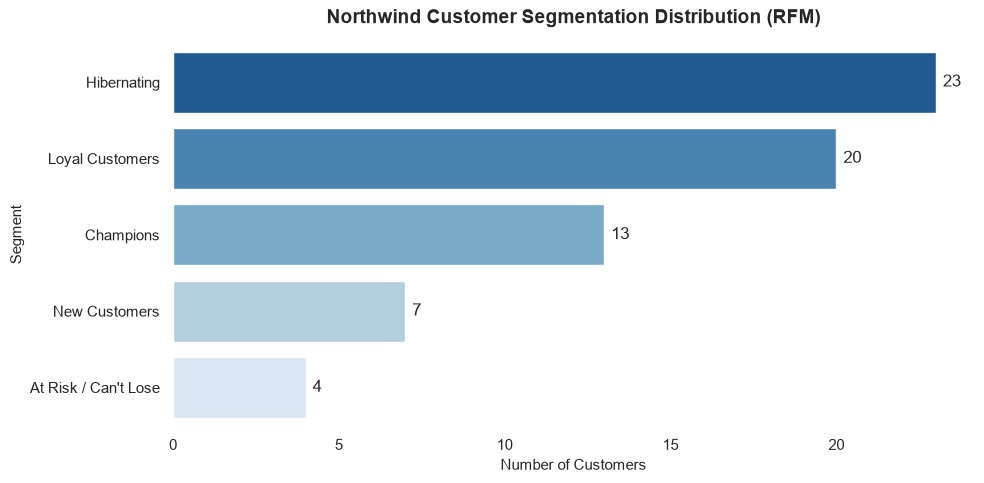

In [704]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# Plot the distribution of customer segments
ax = sns.countplot(
    y='segment', 
    data=df_rfm_scored, 
    order=df_rfm_scored['segment'].value_counts().index,
    palette='Blues_r'
)

plt.title('Northwind Customer Segmentation Distribution (RFM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=11)
plt.ylabel('Segment', fontsize=11)

# Add data labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=5)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [705]:
# 1. Copy the dataframe and force companyName back to a column if it became the index
df_report = df_rfm_scored.copy()
if 'companyName' not in df_report.columns:
    df_report = df_report.reset_index()

# 2. Group the dataset by segment
grouped = df_report.groupby('segment')

for segment_name, group in grouped:
    print("-" * 60)
    print(f"📦 SEGMENT: {segment_name.upper()} ({len(group)} Companies)")
    print("-" * 60)
    
    # Sort by monetary value within the segment so top spenders are first
    sorted_group = group.sort_values(by='Monetary Score', ascending=False)
    
    for idx, row in sorted_group.iterrows():
        company = row['companyName']
        print(f"• {company:<40} | Spend: ${row['Monetary Score']:,.2f} | (R:{row['Recency Score']} F:{row['Frequency Score']} M:{row['Monetary Score']})")
    print("\n")

------------------------------------------------------------
📦 SEGMENT: AT RISK / CAN'T LOSE (4 Companies)
------------------------------------------------------------
• Mère Paillarde                           | Spend: $5.00 | (R:1 F:4 M:5)
• Berglunds snabbköp                       | Spend: $5.00 | (R:1 F:5 M:5)
• Seven Seas Imports                       | Spend: $4.00 | (R:1 F:3 M:4)
• Vaffeljernet                             | Spend: $4.00 | (R:2 F:4 M:4)


------------------------------------------------------------
📦 SEGMENT: CHAMPIONS (13 Companies)
------------------------------------------------------------
• Ernst Handel                             | Spend: $5.00 | (R:5 F:5 M:5)
• Save-a-lot Markets                       | Spend: $5.00 | (R:5 F:5 M:5)
• Rattlesnake Canyon Grocery               | Spend: $5.00 | (R:5 F:5 M:5)
• Hungry Owl All-Night Grocers             | Spend: $5.00 | (R:5 F:5 M:5)
• Folk och fä HB                           | Spend: $5.00 | (R:4 F:5 M:5)
• Whit